### Using `private methods`

In [88]:
class admin:
    __password = 'admin123'

    def __init__(self, name, id):
        self.name = name
        self.id = id
    
    def show(self):
        return self.__password

In [89]:
p = admin('king', 652626)

p.show()

'admin123'

---

### Using `multi class inheritence`

In [90]:
class car_parts:
    def __init__(self, vehicle_type, tyres):
        self.vehicle_type = vehicle_type
        self.tyres = tyres
    
    @property
    def show(self):
        print(f"The car is {self.vehicle_type} Body, and with {self.tyres} tyres")

    # YOU CANNOT USE VARIABLE FROM CHILD CLASS IN PARENT CLASS, CAN DO VICE-VERSA

    
    def hello(self):
        print('Hello this is Biswajeet Pradhan')    


class toyota(car_parts):
    def __init__(self, color, vehicle_type, tyres):            # make sure what ever objects from parent you want to use, you must mention them in the child's "__init__" as well
        self.color = color
    
        super().__init__(vehicle_type, tyres)                   # if you want to use parent class, then you have to put "super().__init__" within the init of child class
    
    @property
    def show(self):
        print(f" BODY TYPE : {self.vehicle_type}\n TYRES : {self.tyres}\n COLOR : {self.color}")

    
    def call(self):
        super().hello()


#### using parent class

In [91]:
c1 = car_parts('Car', 4)

c1.show

The car is Car Body, and with 4 tyres


#### using child class

In [92]:
c2 = toyota('Red', 'Car', 4)
c3 = toyota(vehicle_type='Truck', tyres=8, color='Black')

c2.show
print()
c3.show

 BODY TYPE : Car
 TYRES : 4
 COLOR : Red

 BODY TYPE : Truck
 TYRES : 8
 COLOR : Black


**Child class object can use all the functions of parent class, but can't be vice-versa**

In [93]:
c2.call()

Hello this is Biswajeet Pradhan


---

### Using `@classmethod`

# The Python Methods Cheat Sheet: `self` vs `cls` vs `static`

In Object-Oriented Programming, there are 3 different types of functions you can put inside a class. Here is exactly when to use each one:

| Method Type | The Decorator | First Parameter | What does it modify? | When to use it (Analogy) |
| :--- | :---: | :---: | :--- | :--- |
| **Instance Method** | *(None)* | `self` | **One specific object.** | **The Mechanic:** Use this when you want to change the color of *one specific car*. It does not affect anyone else's car. |
| **Class Method** | `@classmethod` | `cls` | **The Master Blueprint.** | **The CEO:** Use this when you want to change a global rule (like a Bank's interest rate). It instantly updates the rule for *every single object* at the same time. |
| **Static Method** | `@staticmethod`| *(None)* | **Nothing.** | **The Calculator:** Use this when you just want a normal, independent math function that happens to live inside the class, but doesn't need to know anything about the Car or the CEO. |

<br>

### The Code Syntax Difference

```python
class BankAccount:
    interest_rate = 0.05  # Global Blueprint Variable
    
    def __init__(self, name):
        self.name = name

    # 1. INSTANCE METHOD (Modifies the specific user)
    def change_name(self, new_name):
        self.name = new_name

    # 2. CLASS METHOD (Modifies the entire bank)
    @classmethod
    def change_interest_rate(cls, new_rate):
        cls.interest_rate = new_rate

    # 3. STATIC METHOD (Doesn't modify anything, just does a task)
    @staticmethod
    def print_bank_hours():
        print("The bank is open from 9 AM to 5 PM.")


In [94]:
%load_ext cudf.pandas

import pandas as pd
import numpy as np

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [95]:
df = pd.DataFrame({
    'integers':[1,2,3,4,5], 
    'alphabets':['a','b','c','d','e'],
    'greetings':['hello','hii','namaste','juhar','holla']
    })
df

,integers,alphabets,greetings
0,1,a,hello
1,2,b,hii
2,3,c,namaste
3,4,d,juhar
4,5,e,holla


In [96]:
np.random.randint(np.arange(51, 1, -1))


array([44, 29,  3, 39, 35, 41, 36, 15,  2,  1,  2,  1,  7,  0, 12, 32, 31,
       23,  0, 19, 25, 12, 17,  2, 18,  6, 15,  6,  3, 20, 13,  1,  5,  1,
       13,  1,  0,  5, 10, 10,  4,  0,  2,  7,  6,  2,  0,  0,  1,  1])

In [97]:
f1 = np.random.randint(1,100,200)
f2 = np.random.randint(50,250,200)
f3 = np.random.randint(400,650,200)
target = np.random.randint(100,500,200)

a = {
    'f1':f1,
    'f2':f2,
    'f3':f3,
    'target':target
}

df = pd.DataFrame(a)
df

,f1,f2,f3,target
0,5,220,606,333
1,13,80,648,473
2,96,111,616,234
3,13,97,615,434
4,9,197,515,155
...,...,...,...,...
195,11,94,580,491
196,55,105,516,228
197,95,249,473,190
198,55,154,588,400


In [98]:
corr = df.corr()
cov = df.cov()

print(corr)
print()
print(cov)



              f1        f2        f3    target
f1      1.000000  0.055178  0.030695 -0.072325
f2      0.055178  1.000000 -0.034671 -0.046018
f3      0.030695 -0.034671  1.000000  0.074348
target -0.072325 -0.046018  0.074348  1.000000

                f1           f2           f3        target
f1      801.101910    92.653065    63.494472   -233.168241
f2       92.653065  3519.600980  -150.329523   -310.969774
f3       63.494472  -150.329523  5341.411432    618.923241
target -233.168241  -310.969774   618.923241  12974.183693


#### Checking for `var()` to know which features are less important

In [99]:
df.var()

f1          801.101910
f2         3519.600980
f3         5341.411432
target    12974.183693
dtype: float64

In [100]:
# checking for rows and features
print(df.shape)

# checking for null values
print(df.isna().sum())

(200, 4)
f1        0
f2        0
f3        0
target    0
dtype: int64


In [101]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   f1      200 non-null    int64
 1   f2      200 non-null    int64
 2   f3      200 non-null    int64
 3   target  200 non-null    int64
dtypes: int64(4)
memory usage: 6.2 KB


In [102]:
df.describe()

,f1,f2,f3,target
count,200.000000,200.000000,200.00000,200.000000
mean,50.560000,146.795000,525.42500,312.415000
std,28.303744,59.326225,73.08496,113.904274
min,1.000000,52.000000,400.00000,101.000000
25%,27.500000,91.000000,457.25000,217.500000
50%,50.500000,149.500000,527.00000,313.500000
75%,76.250000,197.000000,592.00000,411.750000
max,97.000000,249.000000,648.00000,498.000000


In [103]:
df.sample(10)

,f1,f2,f3,target
163,16,233,484,152
42,19,128,500,233
179,15,175,623,357
21,5,145,459,347
162,34,156,437,211
168,7,183,450,177
141,38,79,504,331
116,79,170,554,101
13,50,125,590,403
69,63,173,559,425


In [104]:
print(f"TOTAL UNIQUE VALUES f1 : {df['f1'].nunique()}")
print(f"TOTAL UNIQUE VALUES f2 : {df['f2'].nunique()}")
print(f"TOTAL UNIQUE VALUES f3 : {df['f3'].nunique()}")

TOTAL UNIQUE VALUES f1 : 87
TOTAL UNIQUE VALUES f2 : 125
TOTAL UNIQUE VALUES f3 : 140


In [105]:
print(f"UNIQUE VALUES IN f1 : {df['f1'].unique()}")
print()
print(f"UNIQUE VALUES IN f2 : {df['f2'].unique()}")
print()
print(f"UNIQUE VALUES IN f3 : {df['f3'].unique()}")

UNIQUE VALUES IN f1 : [ 5 13 96  9 46 83 61 90 14 85  1 50 94 26 18  8 25 51 60 88 93 20 92 86
 42 30 53 91 52 80 55 17 32 78 59 19 38 73 54 16 72 10 33 89 62 34 82 12
 65 81 79 68 77 56 63  2 41 24 21 37 57 66 74 75 43 67 49  7 71 97 28 22
 48  3 31 45 64 87 47 15 29 23 58 76 84 11 95]

UNIQUE VALUES IN f2 : [220  80 111  97 197 124  77 194 155 219  87 188 180 125 244 183  69  74
 116 166 145 192 165  54  52  64 160 153 176 201 217 106 221 193  56 151
 240 231 128 211 150 182 184 143 181 215 195  83 132 118 224 130 233 228
 142 163  82  81 173 214 144 241 138  84  62 159 139 243 200  70 113 149
 109 191  61  53  67 206 222 115 208  76 230  94 205 170 123 119 203 235
 134 141 112  78 213 104 172  79  88  58 161 232 174  92 223 168 133  93
 229 156  60 146  68 204  86  96 175 239 100 126 196 105 249 154  95]

UNIQUE VALUES IN f3 : [606 648 616 615 515 522 571 646 527 403 434 491 419 590 552 467 462 609
 605 427 593 459 438 534 507 437 428 607 620 562 604 480 518 572 643 644
 557 517 592

Currently there is no null values found,

But hypothetically speaking, if there is any null values, we have multiple ways to deal with them

Numerical Data
1. mean imputation
2. KNN

Categorical Data
1. Mode imputation
2. KNN


<Axes: >

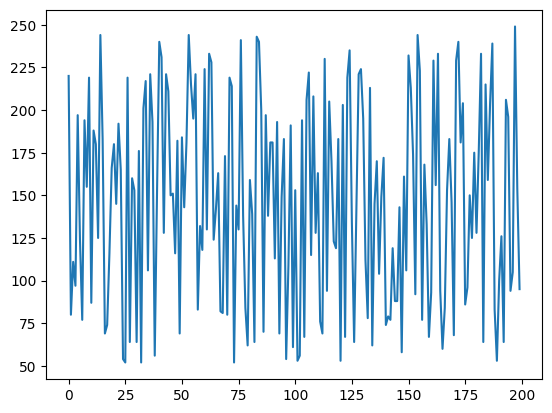

In [106]:
df['f2'].plot()

#### Since there are no null values, we will manually be inserting some null values in feature `f2`

In [107]:
df['f2'] = np.where(df['f2'] > 200, np.nan, df['f2'])

In [108]:
df['f2'].sample(6)

183    64.0
150     NaN
133     NaN
115     NaN
14      NaN
17     74.0
Name: f2, dtype: float64

In [109]:
df['f2'].isna().sum()       # total null values in feature f2 is 99 out of 200 samples

np.int64(48)

In [110]:
df['f2'].describe()

count    152.000000
mean     122.460526
std       45.847556
min       52.000000
25%       79.750000
50%      124.500000
75%      161.500000
max      200.000000
Name: f2, dtype: float64

<Axes: >

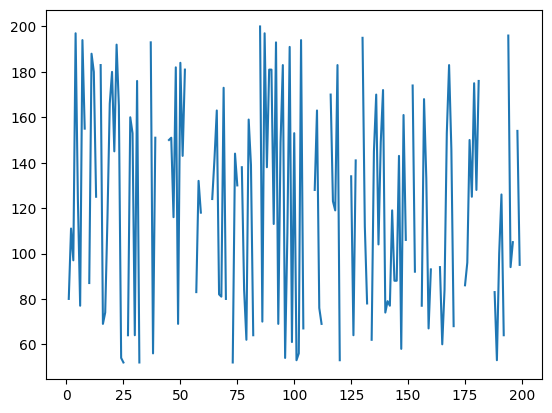

In [111]:
df['f2'].plot()

## type : 1 -- Using Mean Imputation

In [112]:
# copying feature f2 into another object

obj1 = df['f2'].copy()
print(f"NULL VALUES IN obj1 : {obj1.isna().sum()}")

mean = df['f2'].mean()

# replacing null values with mean
obj1 = obj1.fillna(mean)

# checking for null values in obj1
print(f"NULL VALUES IN obj1 : {obj1.isna().sum()}")

NULL VALUES IN obj1 : 48
NULL VALUES IN obj1 : 0


<Axes: >

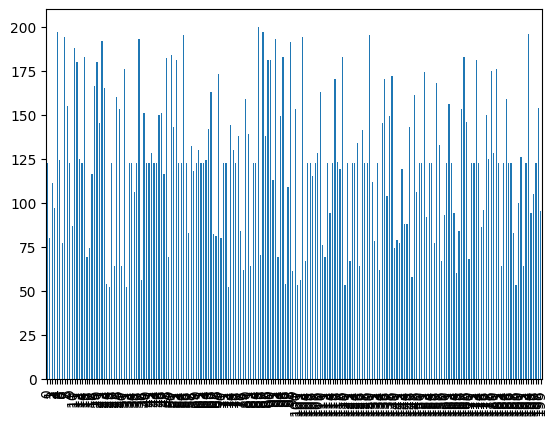

In [113]:
obj1.plot(kind='bar')

<Axes: >

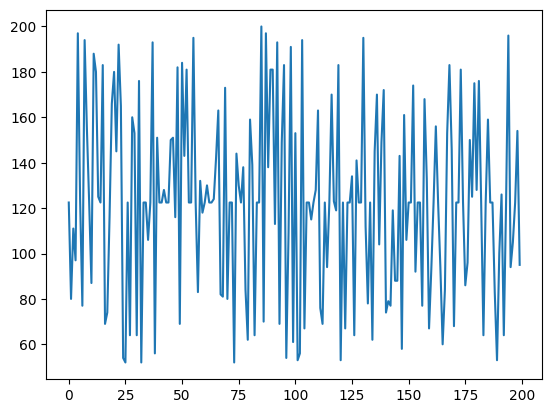

In [114]:
obj1.plot()

## type : 2 -- Using KNN Imputation

In [115]:
# importing KNN 
from sklearn.impute import KNNImputer

In [116]:
obj2 = df['f2'].copy()
print(f"NULL VALUES IN obj2 : {obj2.isna().sum()}")

knn = KNNImputer(n_neighbors=5)       # by default KNN takes mean as the imputation value

obj2 = knn.fit_transform(obj2.values.reshape(-1,1))

obj2 = pd.Series(obj2.flatten())

print(f"NULL VALUES IN obj2 : {obj2.isna().sum()}")



NULL VALUES IN obj2 : 48
NULL VALUES IN obj2 : 0


<Axes: >

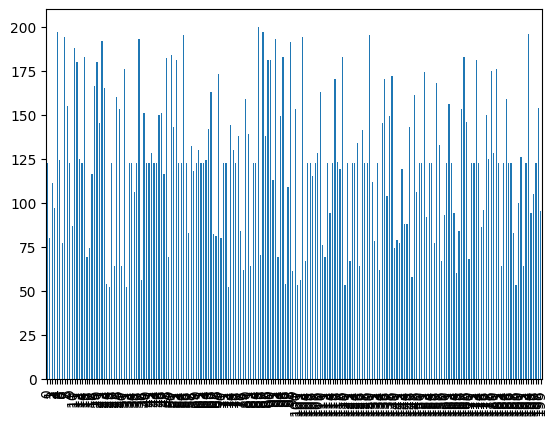

In [117]:
obj2.plot(kind='bar')

<Axes: >

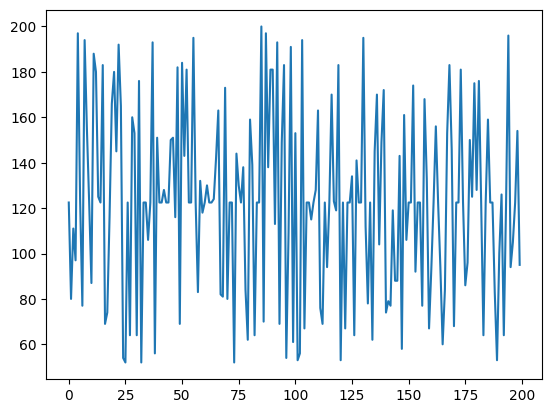

In [118]:
obj2.plot()

In [119]:
pd.concat([obj1, obj2], axis=1, keys=['obj1', 'obj2'])

,obj1,obj2
0,122.460526,122.460526
1,80.000000,80.000000
2,111.000000,111.000000
3,97.000000,97.000000
4,197.000000,197.000000
...,...,...
195,94.000000,94.000000
196,105.000000,105.000000
197,122.460526,122.460526
198,154.000000,154.000000


### Applying mean imputation on real df

In [120]:
df['f2'] = df['f2'].fillna(df['f2'].mean())

In [121]:
df['f2'].isna().sum()

np.int64(0)

### Checking for outliers

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

In [123]:
df

,f1,f2,f3,target
0,5,122.460526,606,333
1,13,80.000000,648,473
2,96,111.000000,616,234
3,13,97.000000,615,434
4,9,197.000000,515,155
...,...,...,...,...
195,11,94.000000,580,491
196,55,105.000000,516,228
197,95,122.460526,473,190
198,55,154.000000,588,400


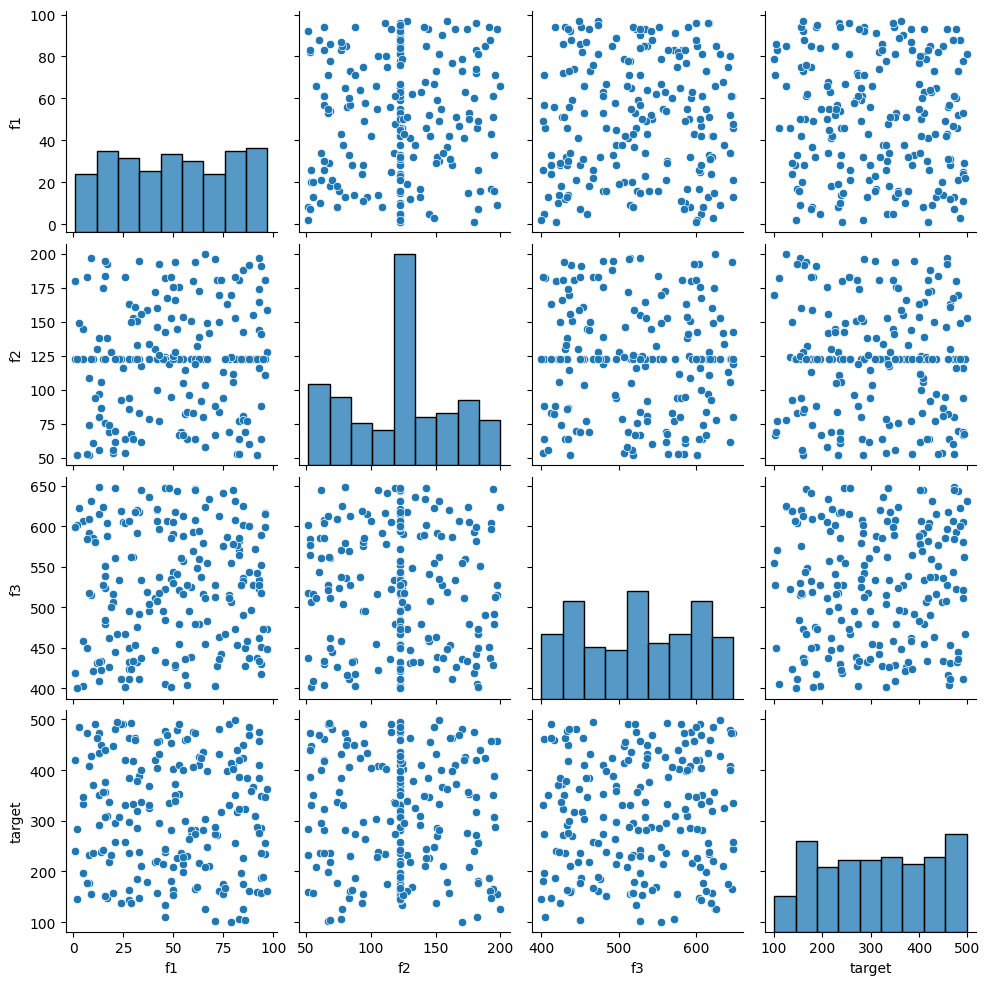

In [124]:
sns.pairplot(df)

### Plotting KDE plot

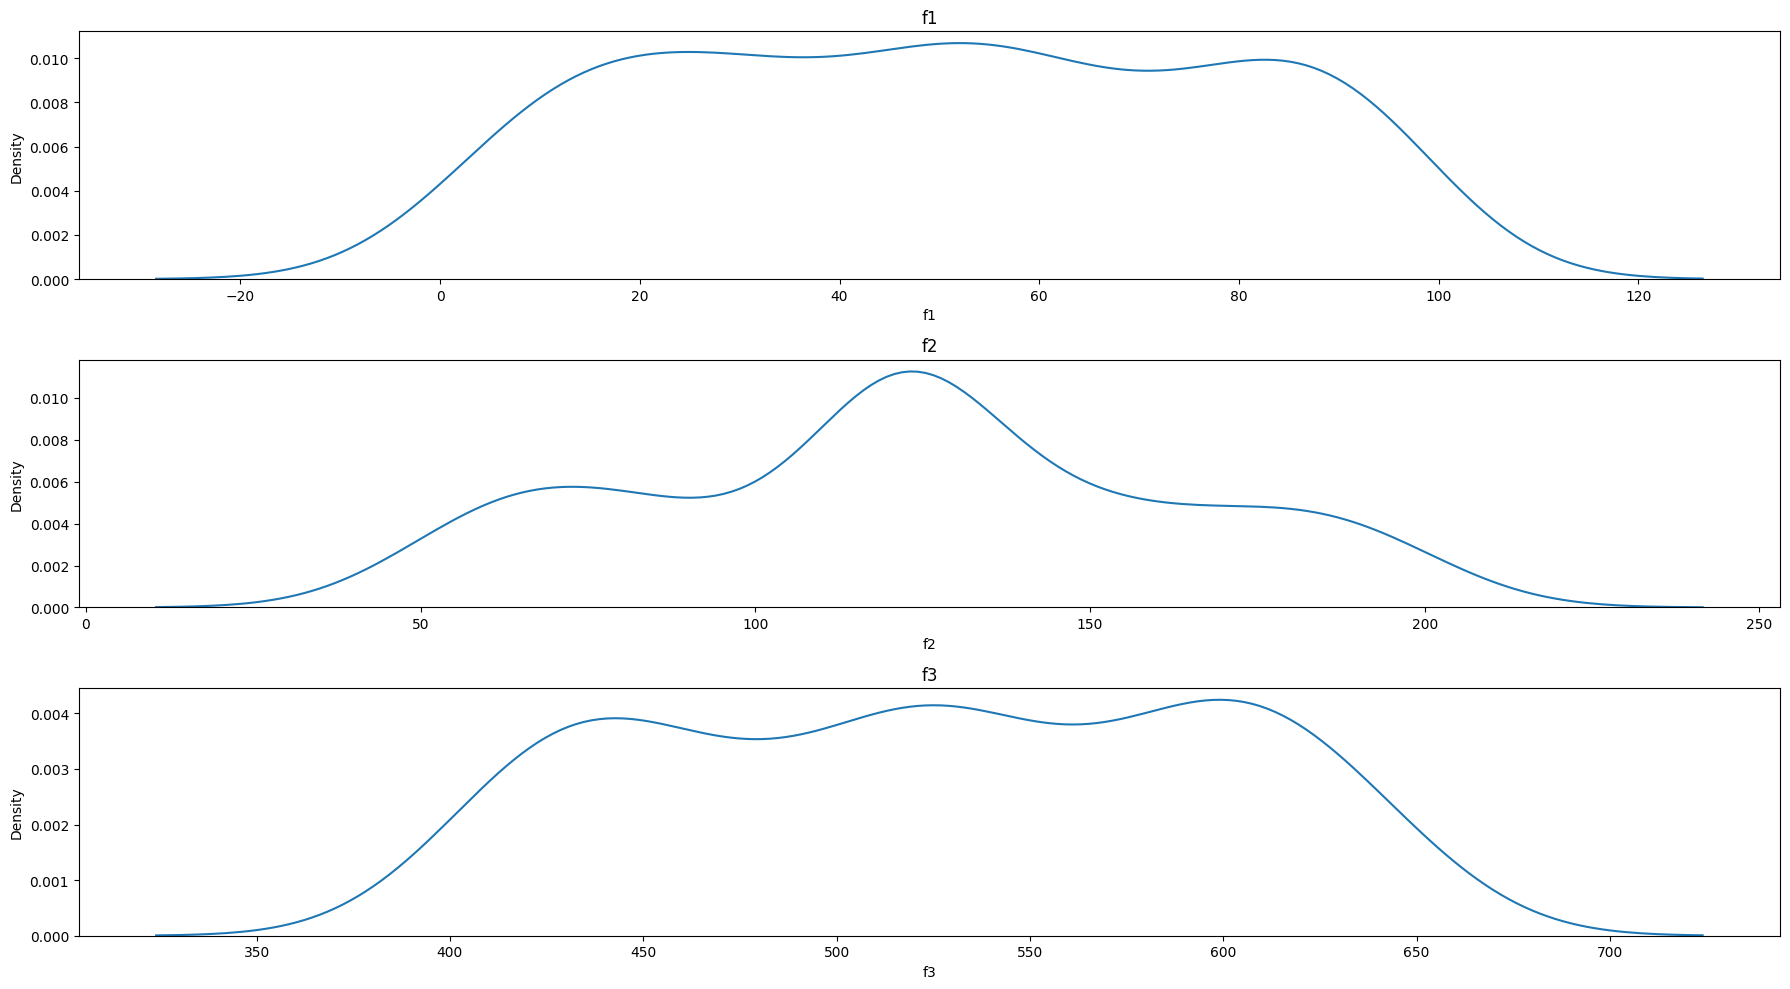

In [125]:
fig, axes = plt.subplots(3, 1, figsize=(18,10))

sns.kdeplot(x=df['f1'], ax=axes[0])
axes[0].set_title('f1')

sns.kdeplot(x=df['f2'], ax=axes[1])
axes[1].set_title('f2')

sns.kdeplot(x=df['f3'], ax=axes[2])
axes[2].set_title('f3')


plt.tight_layout()
plt.show()

### Plotting box plot

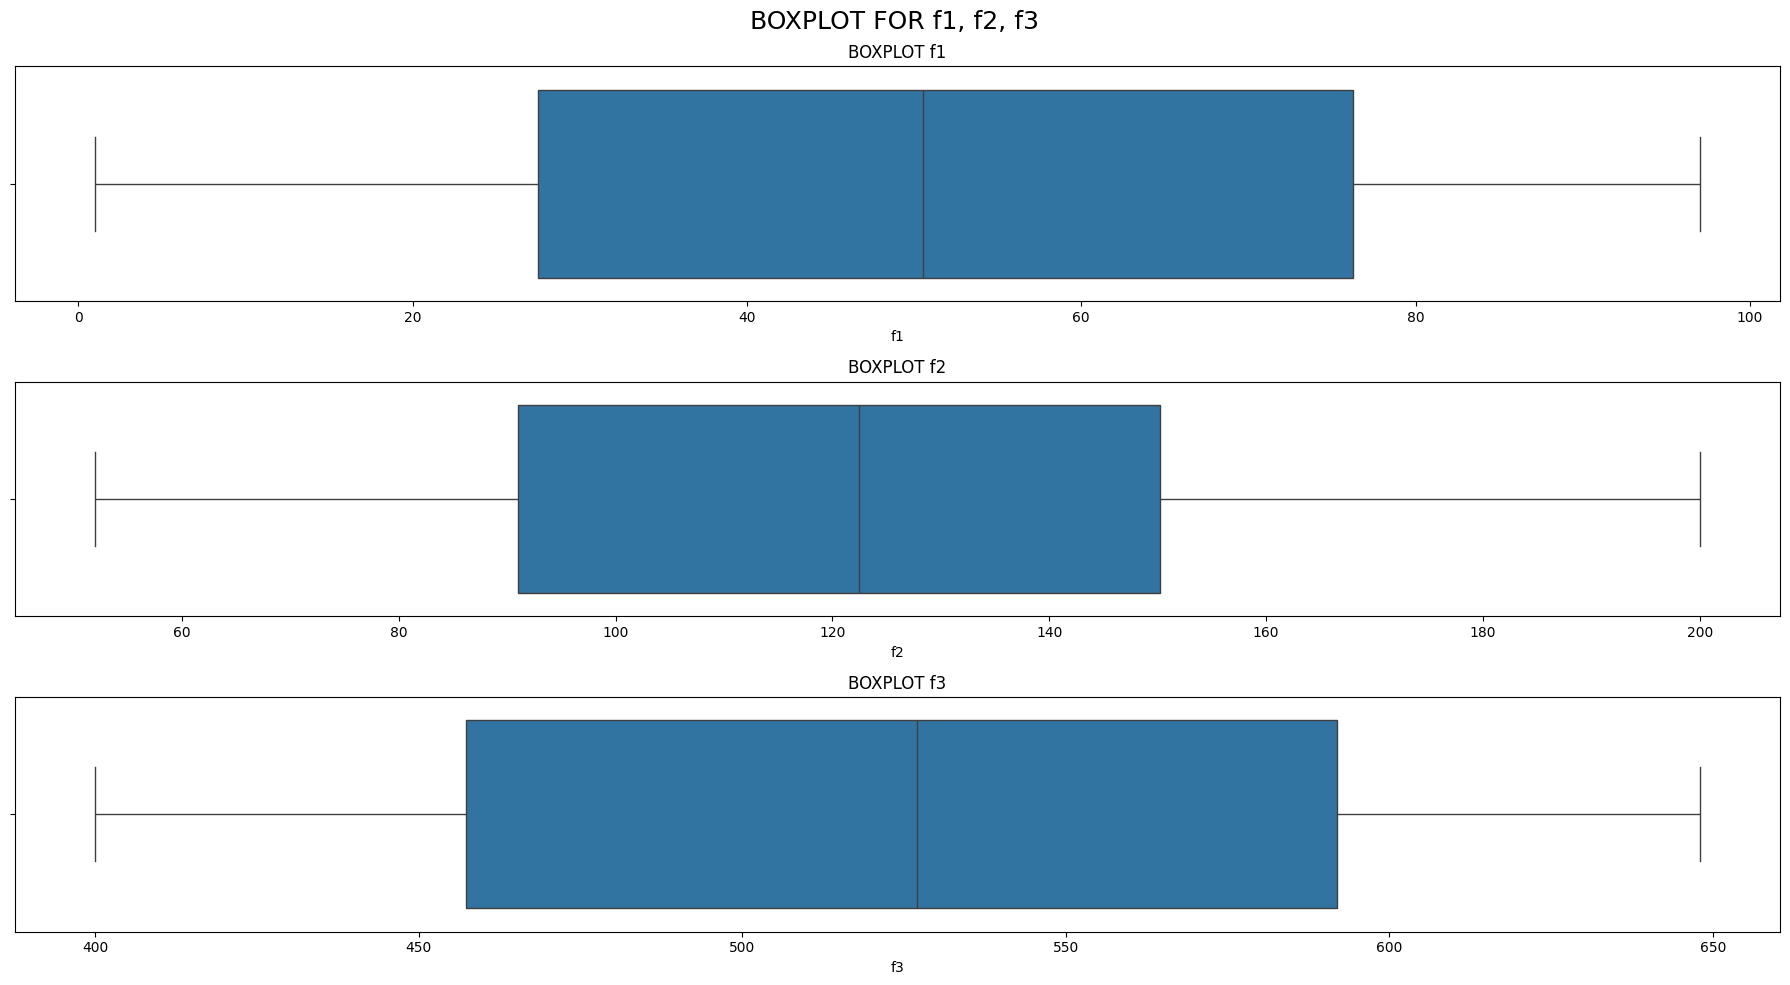

In [126]:
fig, axes = plt.subplots(3, 1, figsize=(18, 10))

sns.boxplot(x=df['f1'], ax=axes[0])
axes[0].set_title('BOXPLOT f1')

sns.boxplot(x=df['f2'], ax=axes[1])
axes[1].set_title('BOXPLOT f2')

sns.boxplot(x=df['f3'], ax=axes[2])
axes[2].set_title('BOXPLOT f3')

plt.suptitle('BOXPLOT FOR f1, f2, f3', fontsize=18)
plt.tight_layout()
plt.show()

### Plotting violin plot

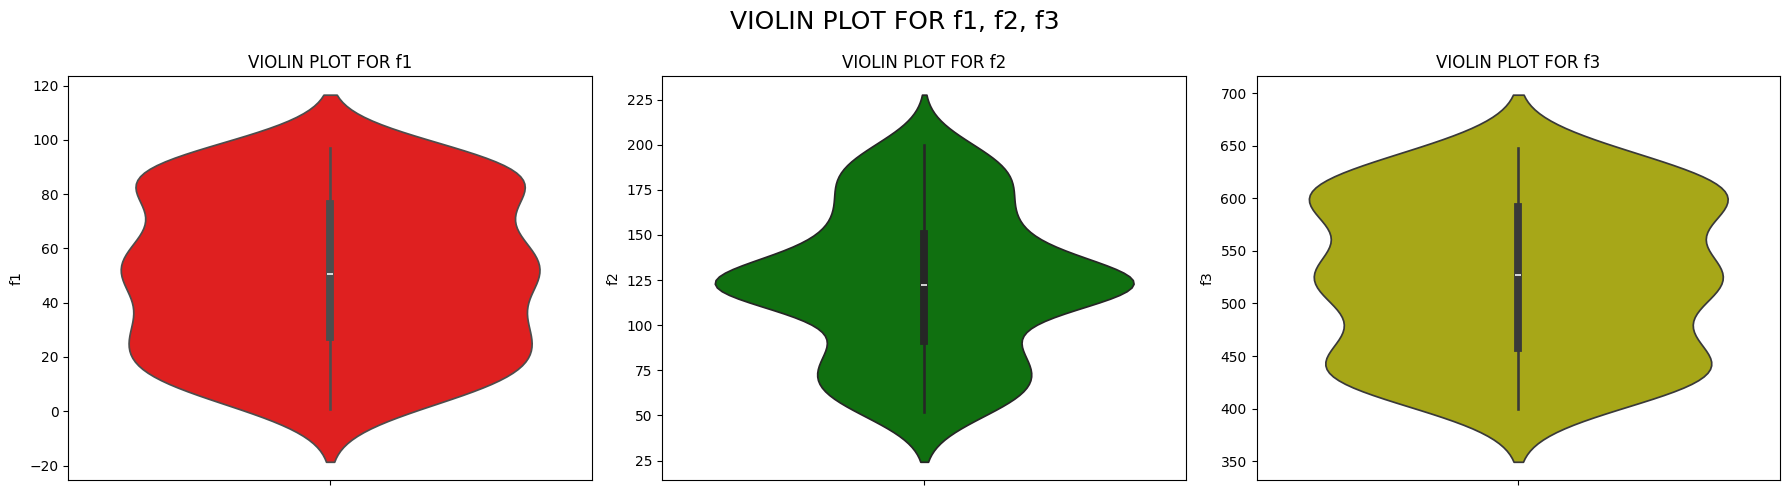

In [148]:

fig, axes = plt.subplots(1, 3, figsize=(18,5))


sns.violinplot(y=df['f1'], ax=axes[0], color='r')
axes[0].set_title('VIOLIN PLOT FOR f1')

sns.violinplot(y=df['f2'], ax=axes[1], color='g')
axes[1].set_title('VIOLIN PLOT FOR f2')

sns.violinplot(y=df['f3'], ax=axes[2], color='y')
axes[2].set_title('VIOLIN PLOT FOR f3')

plt.suptitle('VIOLIN PLOT FOR f1, f2, f3', fontsize=18)
plt.tight_layout()
plt.show()

In [135]:
df['f1']

0       5
1      13
2      96
3      13
4       9
       ..
195    11
196    55
197    95
198    55
199    49
Name: f1, Length: 200, dtype: int64

In [156]:
print(df.var().sort_values(ascending=True))
print()
print(df.corr())
print()
print(df.cov())

f1          801.101910
f2         1594.983734
f3         5341.411432
target    12974.183693
dtype: float64

              f1        f2        f3    target
f1      1.000000  0.090489  0.030695 -0.072325
f2      0.090489  1.000000 -0.050783 -0.044321
f3      0.030695 -0.050783  1.000000  0.074348
target -0.072325 -0.044321  0.074348  1.000000

                f1           f2           f3        target
f1      801.101910   102.286763    63.494472   -233.168241
f2      102.286763  1594.983734  -148.227255   -201.616900
f3       63.494472  -148.227255  5341.411432    618.923241
target -233.168241  -201.616900   618.923241  12974.183693
